# QUOPS with CUDA-Q

QUOPS measures the largest computationally relevant quantum circuit hardware can execute within a specified accuracy threshold and how quickly it can do so. 


## 1. Accuracy: process polarization

For width $w$ and process/entanglement fidelity $F_e(C)$ between the ideal and implemented channels,

$$
\gamma(C)=\frac{4^wF_e(C)-1}{4^w-1},
\qquad
\bar\gamma_{w,s}=\mathbb E_{C\sim P_{w,s}}[\gamma(C)].
$$

Ideal execution has $\gamma=1$; complete depolarization has $\gamma=0$. This is channel accuracy, not the success probability of one output string. In a logical experiment, $w$ counts encoded computational qubits.



In [10]:
import cudaq
import numpy as np
import pandas as pd
from importlib.metadata import version
from platform import platform, python_version
from time import perf_counter
from typing import Callable
from IPython.display import display
from src import *

cudaq.reset_target()
cudaq.set_target("density-matrix-cpu")
# cudaq.set_target("qpp-cpu")
# cudaq.set_target("nvidia", option="fp32") # gpu accelerated statevector simulator
# cudaq.set_target("nvidia", option="fp64") # Higher arithmetic precision and memory use.


# noise = None
noise = make_helios1_noise()
# noise = make_depolarizing_noise(p_1q=0.004, p_2q=0.02) # Nonidentity-Pauli probabilities, not gate infidelities.


shots = 256 # Shots for each BR, RR and REF circuit.
num_circuits = 16 # Independent forward-circuit draws at each shape.
num_mirrors = 1 # Fresh mirror randomizations for each forward circuit.
bootstrap_resamples = 2000 # Resample the acquired data to estimate uncertainty; no new quantum shots.
familywise_alpha = 0.05 # The paper gives 5% to the gated score tests and 5% to the remaining region tests.
seed = 2026
rc_style = "pauli_frame" # Randomize reference circuits while preserving their ideal action.

# Record the environment used by this execution, independently of the saved outputs.
run_environment = {"Python": python_version(), "platform": platform(), "CUDA-Q": cudaq.__version__, **{package: version(package) for package in ("numpy", "pandas", "matplotlib", "scipy")}}
display(pd.Series(run_environment, name="Runtime").to_frame())


,Runtime
Python,3.11.16
platform,Linux-5.15.49-linuxkit-aarch64-with-glibc2.39
CUDA-Q,CUDA-Q Version 0.0.0+c27087e9e9cf (https://git...
numpy,2.4.6
pandas,3.0.5
matplotlib,3.11.1
scipy,1.17.1


## 2. Circuit shape and mirror measurements

Random CNOT pairings alternate with Pauli rotations, with axes and angles sampled independently and uniformly:

$$R_P(\theta)=e^{-i\theta P/2},\qquad P\in\{X,Y,Z\},\quad\theta\in[0,2\pi).$$

**Width** $w$ counts qubits. **Paper depth** $d$ counts elementary layers, so there are $d/2$ CNOT/rotation pairs. $\zeta$ is the active-qubit fraction in the final pair. **Forward size** counts qubit participations:

$$s=N_{R_P}+2N_{\rm CX}.$$


### BR, RR and REF

MCFE uses mirrors with known ideal output strings. With implementation $g$, randomized reference compiler $g_{\rm ref}$ and local-Clifford caps $L,L'$ (rightmost acts first),

$$
\begin{aligned}
M_{\rm BR}&=L'g_{\rm ref}(C^\dagger)g(C)L,\\
M_{\rm RR}&=L'g_{\rm ref}(C^\dagger)g_{\rm ref}(C)L,\\
M_{\rm REF}&=L'L.
\end{aligned}
$$

BR probes the circuit; RR and REF estimate reference and cap/readout contributions. If $\hat h_k$ is the fraction of shots at Hamming distance $k$ from a mirror's target, its effective polarization is

$$\hat\lambda=\frac{\sum_{k=0}^{w}(-1/2)^k\hat h_k-4^{-w}}{1-4^{-w}}.$$



In [11]:
widths = (3, 4) 
depths = (4, 6) 
zeta = 1.0 # Active-qubit fraction in the final pair.

# Keep only shapes inside the paper's utility cone: width**2 <= size <= width**3.
shapes = default_shape_schedule([{"width": w, "depth": d, "zeta": zeta} for w in widths for d in depths if in_utility_cone(w, shape_size(w, d, zeta))])

# Fix the score sequence S before drawing or inspecting any measurement data.
score_width = max(widths) # Tutorial choice; choose the expected best width using prior information.
score_sequence = [(shape["width"], shape["size"]) for shape in shapes if shape["width"] == score_width]

# NumPy draws circuits and caps; CUDA-Q uses its seed for shot/noise sampling.
rng = np.random.default_rng(seed)
cudaq.set_random_seed(seed)

# Retain each circuit/mirror observation and update one live table in place.
rows = []
data = pd.DataFrame(rows)
live_table = display(data, display_id=True)

scan_started = perf_counter() 

for shape in shapes:
    
    width, depth, size = shape["width"], shape["depth"], shape["size"]
    
    for circuit_index in range(num_circuits):
        
        # Draw the CNOT pairings, active subset, rotation axes and angles.
        C = sample_quops_circuit(width, depth, shape["zeta"], seed=rng)
        C_inverse = adjoint_C(C) # Reverse this exact sampled circuit.

        # Reuse C across its mirrors; independently drawn C circuits define the bootstrap clusters.
        for mirror_index in range(num_mirrors):
            
            # Independent caps give each mirror a known ideal target 
            br_caps = sample_mcfe_caps(width, seed=rng)
            L_br, L_prime_br, target_bits_br = br_caps.initial, br_caps.final, br_caps.target
            
            rr_caps = sample_mcfe_caps(width, seed=rng)
            L_rr, L_prime_rr, target_bits_rr = rr_caps.initial, rr_caps.final, rr_caps.target
            
            ref_caps = sample_mcfe_caps(width, seed=rng)
            L_ref, L_prime_ref, target_bits_ref = ref_caps.initial, ref_caps.final, ref_caps.target

            # Randomize each reference independently, preserving its ideal operation.
            rc_C_inverse_br = randomized_compilation(C_inverse, seed=rng, style=rc_style)
            rc_C_rr = randomized_compilation(C, seed=rng, style=rc_style)
            rc_C_inverse_rr = randomized_compilation(C_inverse, seed=rng, style=rc_style)

            # Time the BR and RR sampling calls for the simulator-rate proxy.
            start_time = perf_counter()
            br_counts = cudaq.sample(BR_kernel, width, L_br, C, rc_C_inverse_br, L_prime_br, shots_count=shots, noise_model=noise)
            rr_counts = cudaq.sample(RR_kernel, width, L_rr, rc_C_rr, rc_C_inverse_rr, L_prime_rr, shots_count=shots, noise_model=noise)
            br_rr_seconds = perf_counter() - start_time

            # REF depends on width only but is included within the second for loop for sake of clarity
            ref_counts = cudaq.sample(REF_kernel, width, L_ref, L_prime_ref, shots_count=shots, noise_model=noise)

            # Convert all Hamming distances from the known target into each mirror's effective polarization.
            gamma_br = effective_polarization_from_counts(br_counts, width, target_bits_br)
            gamma_rr = effective_polarization_from_counts(rr_counts, width, target_bits_rr)
            gamma_ref = effective_polarization_from_counts(ref_counts, width, target_bits_ref)
            gamma = normalized_mcfe_polarization(gamma_br, gamma_rr, gamma_ref)

            # Keep component estimates for ensemble inference and BR/RR shots plus timing for the rate.
            rows.append({"shape": f"w={width},s={size}", "width": width, "depth": depth, "size": size, "zeta": shape["zeta"], "circuit_index": circuit_index, "mirror_index": mirror_index, "gamma_br": gamma_br, "gamma_rr": gamma_rr, "gamma_ref": gamma_ref, "gamma": gamma, "br_rr_seconds": br_rr_seconds, "m1_m2_shots": int(br_counts.get_total_shots() + rr_counts.get_total_shots())})
            data = pd.DataFrame(rows)
            live_table.update(data)

scan_seconds = perf_counter() - scan_started
run_settings = {"target": cudaq.get_target().name, "noise": "Helios-1-inspired; calibration 2025-11-05", "shape_count": len(shapes), "score_sequence": score_sequence, "circuits_per_shape": num_circuits, "mirrors_per_circuit": num_mirrors, "shots_per_mirror": shots, "seed": seed, "randomized_compilation": rc_style, "bootstrap_resamples": bootstrap_resamples, "familywise_alpha": familywise_alpha, "scan_wall_seconds": round(scan_seconds, 3)}
display(pd.Series(run_settings, name="Physical scan").to_frame())


,shape,width,depth,size,zeta,circuit_index,mirror_index,gamma_br,gamma_rr,gamma_ref,gamma,br_rr_seconds,m1_m2_shots
0,"w=3,s=10",3,4,10,1.0,0,0,1.000000,0.982143,0.994048,1.012067,0.374871,512
1,"w=3,s=10",3,4,10,1.0,1,0,0.994048,0.994048,1.000000,0.997019,0.379916,512
2,"w=3,s=10",3,4,10,1.0,2,0,0.997024,0.982143,1.000000,1.006047,0.363354,512
3,"w=3,s=10",3,4,10,1.0,3,0,0.994048,0.991071,1.000000,0.998515,0.373115,512
4,"w=3,s=10",3,4,10,1.0,4,0,1.000000,0.997024,0.994048,1.004485,0.393423,512
...,...,...,...,...,...,...,...,...,...,...,...,...,...
59,"w=4,s=24",4,6,24,1.0,11,0,0.988235,0.981618,1.000000,0.997446,0.639393,512
60,"w=4,s=24",4,6,24,1.0,12,0,0.985294,0.972059,1.000000,0.999355,0.671934,512
61,"w=4,s=24",4,6,24,1.0,13,0,0.997059,0.980882,0.988235,1.012703,0.765537,512
62,"w=4,s=24",4,6,24,1.0,14,0,0.991176,0.991176,0.994118,0.998520,0.676338,512


,Physical scan
target,density-matrix-cpu
noise,Helios-1-inspired; calibration 2025-11-05
shape_count,4
score_sequence,"[(4, 16), (4, 24)]"
circuits_per_shape,16
mirrors_per_circuit,1
shots_per_mirror,256
seed,2026
randomized_compilation,pauli_frame
bootstrap_resamples,2000


## 3. Accuracy, QUOPS and rate

**Average each mirror ensemble first, then normalize**:

$$\widehat{\bar\gamma}_{w,s}=\frac{\overline{\hat\lambda}_{\rm BR}}{\sqrt{\overline{\hat\lambda}_{\rm RR}\,\overline{\hat\lambda}_{\rm REF}}}.$$

### The paper's QUOPS test

With $\gamma_0=1/\sqrt e$, the normal test and lower confidence bound are:

$$p=1-\Phi\!\left(\frac{\widehat{\bar\gamma}_{w,s}-\gamma_0}{\widehat{\mathrm{SE}}}\right),\qquad L_{95}=\widehat{\bar\gamma}_{w,s}-\Phi^{-1}(0.95)\widehat{\mathrm{SE}}.$$

A single test **passes** when $p\le0.05$, equivalently $L_{95}\ge\gamma_0$. The bootstrap estimates SE from independent circuit clusters, keeping each circuit's BR/RR observations together and resampling REF independently. MCFE and the normal sampling approximation retain the paper's assumptions. An undefined test is marked invalid.

### Score: gated tests at 95% confidence

Choose an ordered sequence $S$ **before inspecting its data**, with strictly increasing sizes inside $w^2\le s\le w^3$. Test each shape at 5%; stop at the first non-pass. $\widehat Q$ is the size of the last shape that passed before stopping, or zero if none passed. Collected data after the gate closes do not enter this score.

### Capability region: Hochberg tests at 90% confidence

The remaining shapes $R$ exclude **all** of $S$. Sort their $m$ p-values and choose the largest $k$ satisfying

$$p_{(k)}\le\frac{0.05}{m-k+1}.$$

The first $k$ shapes pass. Let $D$ contain these passes and the gated passes. The estimated region is their downward closure,

$$\widehat{\mathcal Q}=\{(w,s):w\le w',\ s\le s'\text{ for some }(w',s')\in D\}.$$

The two 5% budgets give the paper's 90% region confidence. Hochberg assumes independent or appropriately positively dependent tests; extending $D$ downward assumes mean polarization does not increase with width or size. A failed test means the threshold was not established. The table distinguishes the test families; its $L_{95}$ column is a per-shape bound, while region decisions use the adjusted p-value.

### Rate

With no discarded shots, the simulator timing proxy is

$$\widehat\Omega_{\rm sim}(w,s)=\frac{2s\,\widehat{\bar\gamma}_{w,s}^{\,2}\,N}{t_{\rm BR+RR}},$$

where $N$ is the combined BR and RR shot count. The highlighted rate uses the gated score's shape.


width,depth,size,test_family,estimated_polarization,lower_bound_95,p_value,adjusted_p_value,decision
3,4,10,Hochberg (R),0.9992,0.9964,0,0,Pass
3,6,15,Hochberg (R),0.9971,0.9941,0,0,Pass
4,4,16,Gated score (S),1.0005,0.9974,0,—,Pass
4,6,24,Gated score (S),0.9876,0.9812,0,—,Pass


Threshold = 0.6065; QUOPS score = 24; score confidence = 95%; region confidence = 90% (paper's normal-test assumptions).


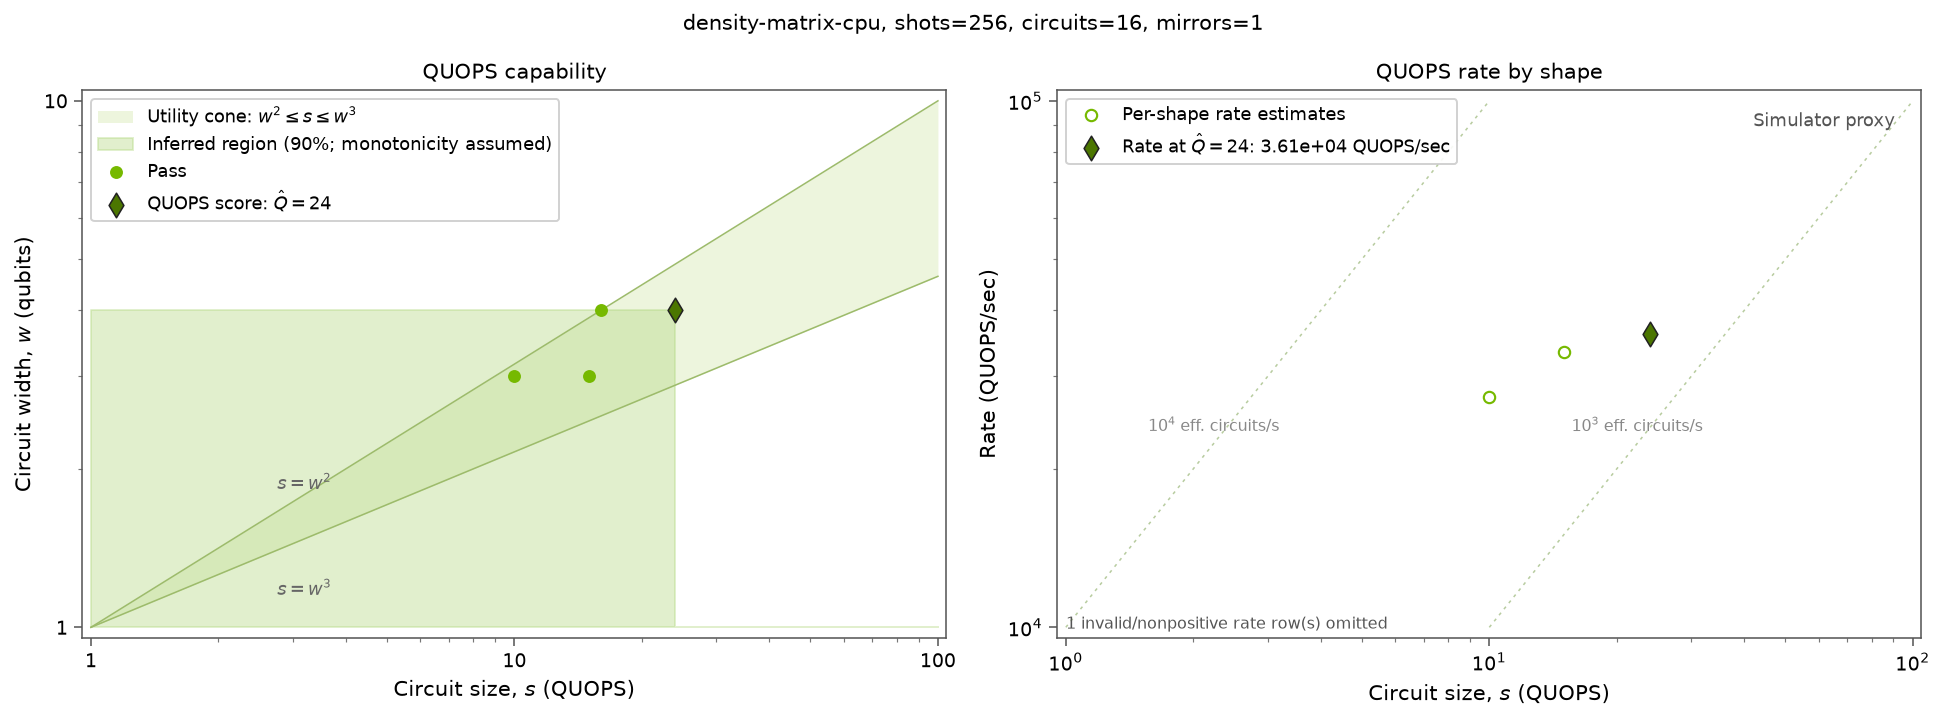

In [12]:
# Estimate polarization and bootstrap uncertainty, then apply the paper's gated and Hochberg tests.
# score_sequence was fixed before acquisition; all remaining declared shapes stay in the region family.
per_shape = summarize_quops_runs(data, familywise_alpha=familywise_alpha, bootstrap_resamples=bootstrap_resamples, seed=seed, declared_shapes=shapes, score_sequence=score_sequence)

# The 95% lower bound is per shape; the Hochberg family decides using adjusted_p_value.
decision_table = per_shape[["width", "depth", "size", "test_family", "mean_polarization", "polarization_lower", "p_value", "adjusted_p_value", "decision"]].rename(columns={"mean_polarization": "estimated_polarization", "polarization_lower": "lower_bound_95"})
decision_table["decision"] = decision_table["decision"].map({"pass": "Pass", "fail": "Fail", "invalid": "Invalid", "not_tested": "Not tested (gate closed)"})
display(decision_table.style.format({"estimated_polarization": "{:.4f}", "lower_bound_95": "{:.4f}", "p_value": "{:.4g}", "adjusted_p_value": "{:.4g}"}, na_rep="—").hide(axis="index"))
print(f"Threshold = {per_shape['threshold'].iloc[0]:.4f}; QUOPS score = {per_shape.attrs['score']}; score confidence = {1-familywise_alpha:.0%}; region confidence = {1-2*familywise_alpha:.0%} (paper's normal-test assumptions).")

# Show the downward-closed capability estimate and the rate at the gated score's shape.
label = f"{cudaq.get_target().name}, shots={shots}, circuits={num_circuits}, mirrors={num_mirrors}"
fig = plot_quops_results(per_shape, label=label)


### Saved study 1: physical capability up to 30 qubits

**34 completed shapes; 30 circuits per shape; one mirror; eight shots per BR/RR/REF component.**


<img src="plots/physical_capability_publication.png" alt="Final physical capability scan under the Helios-1-inspired surrogate" width="650">



## Studying Logical implementation of QUOPS using CUDA-Q 

## 4. P0: synthesize a logical BR

**P0: logical operations → P1: device placement → P2: encoded implementation.** 




Peak logical qubits                  5
T and T-dagger operations            0
Total logical operations           233
Serial action-depth upper bound    233
Name: P0: before synthesis, dtype: int64

Peak logical qubits                   5
T and T-dagger operations          1972
Total logical operations           5648
Serial action-depth upper bound    5648
Name: P0: after Clifford+T synthesis, dtype: int64

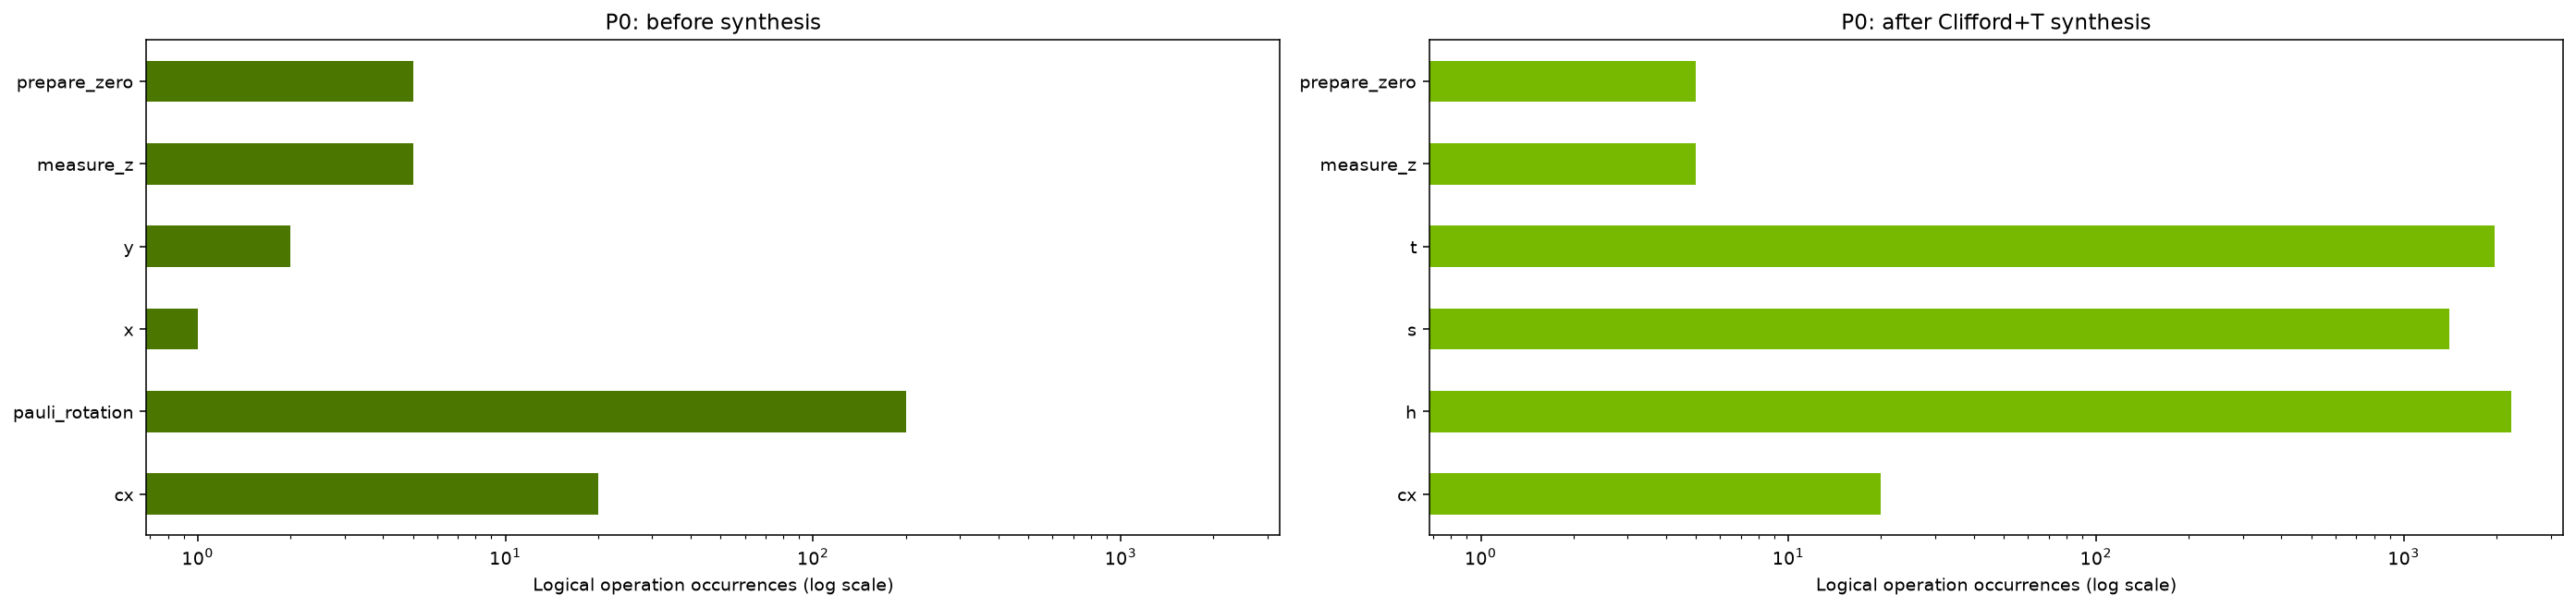

In [13]:
import cudaq.logical

# Fix one BR workload for the synthesis, placement and encoding comparisons.
width, depth, zeta = 5, 10, 1.0
seed = 2026
gate_synthesis_precision = 1e-4

# Prepare the forward circuit, its randomized inverse and known-output caps for one fixed BR.
C = sample_quops_circuit(width, depth, zeta, seed=seed)
C_inverse = adjoint_C(C)
rc_C_inverse = randomized_compilation(C_inverse, seed=seed + 1, style="pauli_frame")
caps = sample_mcfe_caps(width, seed=seed + 2)
L = caps.initial
L_prime = caps.final

@cudaq.kernel
def BR(width: int, L: Callable[[cudaq.qview], None], C: Callable[[cudaq.qview], None], rc_C_inverse: Callable[[cudaq.qview], None], L_prime: Callable[[cudaq.qview], None]):
    qubits = cudaq.qvector(width) # P0 computational qubits; P2 later expands them into encoded blocks.
    L(qubits)
    C(qubits)
    rc_C_inverse(qubits)
    L_prime(qubits)
    mz(qubits)
    

# This target specializes arguments and prepares the Quake IR required by the P0 importer.
target = cudaq.logical.targets.Target.from_backend("quops_portable_p0", cudaq.logical.targets.ProgramBackend(next_backend=cudaq.logical.targets.TerminalBackend()))
cudaq.set_target(target)

# True marks BR as the entry point; bind its width and callable circuits.
compiled_br = BR.beta_reduction(True, width, L, C, rc_C_inverse, L_prime)

# Import the prepared CUDA-Q compiler representation into a portable logical P0 Build.
source_p0 = cudaq.logical.compiler.import_quake(str(compiled_br.mlir_module))

# Approximate the imported rotations in Clifford+T to the per-rotation precision.
p0 = cudaq.logical.compiler.synthesize(source_p0, gate_set=cudaq.logical.compiler.gate_sets.clifford_t, precision=gate_synthesis_precision)

# Count logical operations before placement or encoding.
resources = cudaq.logical.estimate(p0, tier=cudaq.logical.estimate.Tier.LOGICAL)
source_resources = cudaq.logical.estimate(source_p0, tier=cudaq.logical.estimate.Tier.LOGICAL) # Compare the operations before synthesis.

# Compare the logical gate inventories before and after synthesis.
fig = plot_p0_comparison(source_resources, resources)


### Saved study 2: synthesis precision


![P0 Clifford, T and combined gate counts versus synthesis precision](plots/p0_br_precision_distinct.png)



## 5. P1: place the logical qubits

The device has one **compute region** with $w$ logical slots and readout support. All $w$ BR owners are placed together in this region.

The table and plot report occupied and free logical slots. Placement does not estimate routing or execution time.


placed_owners          5
regions_used           1
relaxed_preferences    0
Name: P1 placement, dtype: int64

,region,capacity,occupied,free
0,compute,5,5,0


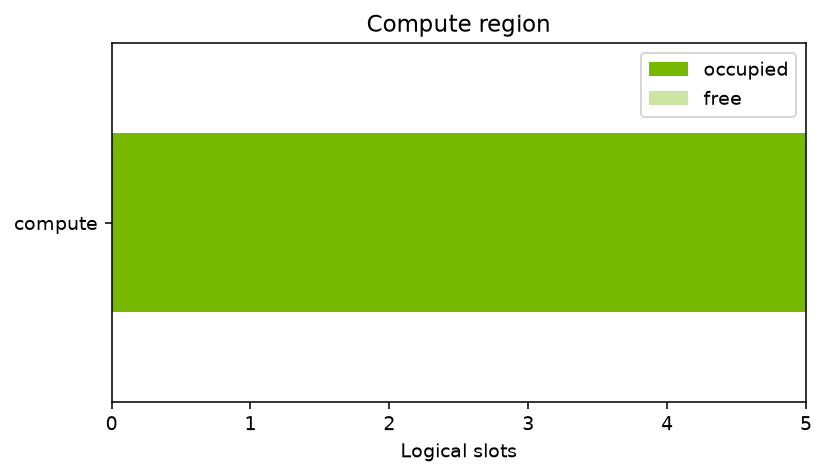

In [14]:
# Declare capacity in logical slots; physical carriers are introduced by the P2 encoding.
builder = cudaq.logical.devices.DeviceBuilder("QUOPSDevice")
compute = builder.logical.add_compute(name="compute", capacity=width, capabilities=(cudaq.logical.architecture.capability.logical_measurement,))
builder.logical.add_stream(cudaq.logical.std.T_STATE, name="t_states", external=True) # State production and delivery costs are outside this model.
device = builder.build()

# Collect P0 logical owners; placement maps these identities to compute slots.
owners = tuple(value for group in p0.values for value in group)

# Keep interacting owners together and require logical readout.
placement_constraints = (cudaq.logical.architecture.colocate(owners), cudaq.logical.architecture.require_capability(cudaq.logical.architecture.capability.logical_measurement), cudaq.logical.architecture.prefer(space=device.logical.compute, for_=cudaq.logical.architecture.lifecycle.ACTIVE))
p1 = cudaq.logical.compiler.place(p0, device=device, placement=placement_constraints)

# Inspect the placed owners and the occupied/free slots in the compute region.
placement_metrics = pd.Series({"placed_owners": len(p1.placement.bindings), "regions_used": len({binding.space for binding in p1.placement.bindings}), "relaxed_preferences": len(p1.placement.relaxed_preferences)}, name="P1 placement")
capacity = pd.DataFrame([{"region": device.logical.compute.name, "capacity": device.logical.compute.capacity, "occupied": len({binding.slot for binding in p1.placement.bindings})}])
capacity["free"] = capacity["capacity"] - capacity["occupied"]
display(placement_metrics, capacity)

# Show logical capacity for the single compute region.
fig = plot_p1_capacity(capacity)


## 6. P2: encode qubits and implement Cliffords

Steane $[[7,1,3]]$ stores **one logical qubit in seven data qubits**, plus reserved syndrome ancillas. A gadget supplies a typed encoded operation.

For the installed convention,

$$H_L\doteq H^{\otimes7},\qquad S_L\doteq(S^\dagger)^{\otimes7},$$

where $\doteq$ denotes equality on the code space up to phase. CX acts transversally between corresponding data carriers. These implementations alone do not prove circuit-level fault tolerance.


In [15]:
code = cudaq.logical.codes.Steane # One logical qubit per block, with seven data carriers and reserved syndrome ancillas.

# implements names the logical operation; patch[Steane] fixes its encoded boundary.
# Gadgets return live blocks that callers pass to subsequent operations.
@cudaq.logical.gadget(implements=cudaq.logical.std.h)
def steane_h(block: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> cudaq.logical.patch[cudaq.logical.codes.Steane]:
    return cudaq.logical.h(block.data) # Apply H to all seven data carriers.

@cudaq.logical.gadget(implements=cudaq.logical.std.s)
def steane_s(block: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> cudaq.logical.patch[cudaq.logical.codes.Steane]:
    return cudaq.logical.sdg(block.data) # Physical S-dagger implements logical S.

@cudaq.logical.gadget(implements=cudaq.logical.std.sdg)
def steane_sdg(block: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> cudaq.logical.patch[cudaq.logical.codes.Steane]:
    return cudaq.logical.s(block.data) # Physical S implements logical S-dagger.

@cudaq.logical.gadget(implements=cudaq.logical.std.cx)
def steane_cx(control: cudaq.logical.patch[cudaq.logical.codes.Steane], target: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> tuple[cudaq.logical.patch[cudaq.logical.codes.Steane], cudaq.logical.patch[cudaq.logical.codes.Steane]]:
    return cudaq.logical.cx(control.data, target.data) # Pair corresponding data carriers.


## 7. P2: implement T with a magic state

The protocol consumes one externally supplied encoded state,

$$|A_L\rangle=T_L|+_L\rangle=\frac{|0_L\rangle+e^{i\pi/4}|1_L\rangle}{\sqrt2}.$$

Apply CX from data to ancilla, measure the ancilla in Z, and apply $S_L$ to the surviving data when the result is 1: $S_LT_L^\dagger=T_L$. Appending $S_L^\dagger$ implements T-dagger.

The estimate excludes magic-state production and delivery.


In [16]:
# Specialize destructive logical Z readout to the selected code.
steane_measure_z = cudaq.logical.gadgets.measure_z(code)

@cudaq.logical.protocol(implements=cudaq.logical.std.t)
def steane_t(block: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> cudaq.logical.patch[cudaq.logical.codes.Steane]:
    # Request one externally supplied encoded magic state and expose its ancilla block.
    magic, = cudaq.logical.request_many(cudaq.logical.std.T_STATE, count=1)
    block, ancilla = cudaq.logical.unpack_resource(magic, like=block, encoding=cudaq.logical.codes.Steane) # Expose the encoded ancilla while retaining the data block.
    block, ancilla = steane_cx(block, ancilla)
    measured = steane_measure_z(ancilla) # Consume the ancilla and obtain the logical Z bit.

    # Apply S for outcome 1; carries keeps the data block available after either branch.
    block, = cudaq.logical.ops.cond(measured, then=lambda block: steane_s(block), else_=lambda block: block, carries=(block,))
    return block

@cudaq.logical.protocol(implements=cudaq.logical.std.tdg)
def steane_tdg(block: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> cudaq.logical.patch[cudaq.logical.codes.Steane]:
    return steane_sdg(steane_t(block)) # S-dagger after T implements T-dagger.


## 8. P2: count encoded resources

For the complete BR,

$$N_A=N_T+N_{T^\dagger},\qquad N_{\rm data}=7B_{\rm peak}.$$

$N_A$ is magic-state demand and $B_{\rm peak}$ is peak live Steane blocks. Templates also reserve ancillas; capacity and live usage are different quantities.

The estimate counts **static vector instructions and both conditional branches**, rather than individual physical gates or execution time. External factories are excluded. This compilation is the zero-syndrome-round baseline.


T-state requests                    1972
Syndrome extractions                   0
Peak encoded blocks                    6
Carriers in peak block templates      78
Name: P2: Steane encoded resources, dtype: int64

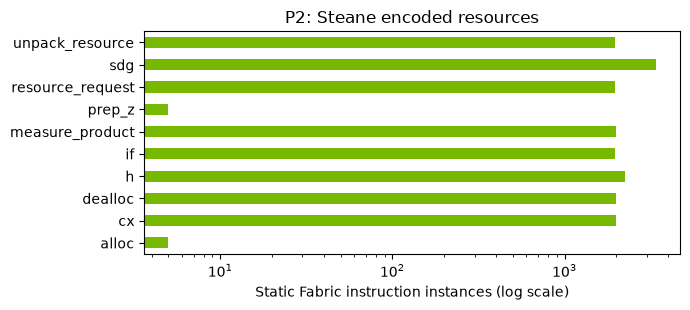

In [17]:
# Supply preparation, readout and gate implementations needed by the synthesized BR.
realizations = (cudaq.logical.gadgets.prepare_zero(code), steane_measure_z, steane_h, steane_s, steane_sdg, steane_cx, steane_t, steane_tdg)

# Link each logical operation to its encoded gadget or protocol.
architecture = cudaq.logical.devices.QECArchitecture("SteaneArchitecture", code.default_encoding, link_roots=realizations)
builder = cudaq.logical.devices.DeviceBuilder(device.name, logical=device.logical)

# Bind compute to Steane and reserve one additional block for T-state injection.
builder.qec.bind(builder.logical.compute, architecture=architecture, block_capacity=width + 1)
p2_device = builder.build()

# Lower the exact P1 program using the selected QEC implementations.
p2 = cudaq.logical.compile(p1, device=p2_device, pipeline=cudaq.logical.compiler.pipelines.qec())

# Static estimates count vector instructions and both branches; one instruction may address many carriers.
p2_resources = cudaq.logical.estimate(p2, tier=cudaq.logical.estimate.Tier.STATIC)

# Retain the zero-round baseline so the next cell can isolate syndrome-extraction cost.
p2_baseline, baseline_resources = p2, p2_resources
show_p2(p2_resources, code)


## 9. P2: add one syndrome round

Extract all Steane checks from the surviving data block **once after each T or T-dagger**, including its injection correction:

$$N_{\rm extraction}=N_T+N_{T^\dagger}=N_A.$$

Reuse the same P1 program and report the added work over the baseline. Magic-state demand stays fixed. Syndromes are recorded; no syndrome-based recovery is applied.


In [ ]:
@cudaq.logical.gadget(implements=cudaq.logical.std.idle)
def steane_checkpoint(block: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> cudaq.logical.patch[cudaq.logical.codes.Steane]:
    block, syndrome = cudaq.logical.extract_syndrome(block, record="checkpoint") # One extraction round; record all checks without recovery.
    return block

# Reuse T injection without registering another implementation of the logical T operation.
injection = cudaq.logical.protocol(steane_t.provider, name="steane_injection_body")

@cudaq.logical.protocol(implements=cudaq.logical.std.t)
def t_with_checkpoint(block: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> cudaq.logical.patch[cudaq.logical.codes.Steane]:
    block = injection(block)
    return steane_checkpoint(block)

@cudaq.logical.protocol(implements=cudaq.logical.std.tdg)
def tdg_with_checkpoint(block: cudaq.logical.patch[cudaq.logical.codes.Steane]) -> cudaq.logical.patch[cudaq.logical.codes.Steane]:
    block = steane_sdg(injection(block)) # Complete T-dagger before extracting the syndrome.
    return steane_checkpoint(block)

# Replace the T/T-dagger implementations and keep the same placed BR.
checkpoint_realizations = tuple(gadget for gadget in realizations if gadget not in (steane_t, steane_tdg)) + (t_with_checkpoint, tdg_with_checkpoint)
checkpoint_architecture = cudaq.logical.devices.QECArchitecture("SteaneCheckpoint", code.default_encoding, link_roots=checkpoint_realizations)
builder = cudaq.logical.devices.DeviceBuilder(device.name, logical=device.logical)
builder.qec.bind(builder.logical.compute, architecture=checkpoint_architecture, block_capacity=width + 1)
p2 = cudaq.logical.compile(p1, device=builder.build(), pipeline=cudaq.logical.compiler.pipelines.qec())
p2_resources = cudaq.logical.estimate(p2, tier=cudaq.logical.estimate.Tier.STATIC)

# Report this one-round BR and its added work over the baseline without checkpoints.
qec_metrics = pd.DataFrame([{"rounds_per_T": 1, "syndrome_extractions": p2_resources.syndrome_rounds, "T_state_requests": p2_resources.resource_requests.get(cudaq.logical.std.T_STATE.name, 0), "static_instructions": p2_resources.total_operations, "additional_instructions": p2_resources.total_operations - baseline_resources.total_operations, "peak_blocks": p2_resources.patches_peak, "peak_template_carriers": p2_resources.patches_peak * code.block.size}]).set_index("rounds_per_T")
display(qec_metrics)


,syndrome_extractions,T_state_requests,static_instructions,additional_instructions,peak_blocks,peak_template_carriers
rounds_per_T,,,,,,
1,1972,1972,31294,13804,6,78


### Saved study 6: code-memory resources

**15 cases:** Steane and rotated-surface distances 3/5/7/9, each with **1/10/100 syndrome rounds** between one encoded-zero preparation and destructive Z-readout.

![Code-template carriers, syndrome support incidences and memory instruction counts](plots/p2_code_memory.png)

Surface distance 3→9 increases data carriers **9→81** and data/check interactions per round **24→288**. Yet all codes have $I(R)=4+7R$ static vector instructions, so those curves overlap. Equal instruction totals can hide different carrier-level work.


